# Creating a forest map for the Veluwe

Created: 2026-07-13  
Author: Stefan Vriend

## Context

Up until this point in the development of the Veluwe Forest Landscape Model, we have been using the [Natura2000 area 'Veluwe'](https://www.natura2000.nl/gebieden/gelderland/veluwe/veluwe-kaart) as our coverage.  
This is the area that is protected under the Birds and Habitats Directives for the European Union. The majority of this area is forested, but it also includes dry and wet heathland, smaller water bodies, and drift sands. Removing these non-forested areas is key to creating a map that accurately represented the Veluwe forests.

## LGN
##### Background
One way to do this is using the maps from LGN (Landelijk Grondgebruik Nederland, translated "national land use Netherlands"). [LGN](https://lgn.nl/english) is a nation-wide map that provides the user with current and accurate information about land use in the Netherlands. Since 2018, LGN is renewed every year. Before that time, a map for every 3-6 years is available.

Resolution of LGN4-7 is 25x25 meter and of LGN2018 and later 5x5 meter.

##### Data availability
Every year by September, the LGN map for the previous year is uploaded to PDOK. At this moment, the 2024 version is available as a Web Map Service (WMS) layer: https://www.pdok.nl/introductie/-/article/landelijk-grondgebruik-nederland-lgn-.  
Older versions are currently only available via a web form to request a download link (https://lgn.nl/bestanden), and will be made available online in the future on 4TU Research Data (e.g., [LGN 2018](https://doi.org/10.4121/8738f896-f49e-4ae7-8671-50ef893a2cee)).

### LGN via PDOK
Whenever we use external data sources, we give preference to data that can be accessed via code only. That way we can easily integrate data retrieval into analytical workflows, such as that of the Veluwe Forest Landscape Model, without requiring each user to manually download files.

In [1]:
library(sf)
library(terra)
#install.packages("httr2"); library(httr2)
#install.packages("png"); library(png)

Linking to GEOS 3.13.0, GDAL 3.10.2, PROJ 9.5.1; sf_use_s2() is TRUE

terra 1.8.42



In [2]:
# Load Natura 2000 geodata
natura2000_sf <- sf::read_sf("https://service.pdok.nl/rvo/natura2000/atom/downloads/natura2000.gpkg")

# Filter the Veluwe Natura2000 from the geometry collection
veluwe_sf <- natura2000_sf %>%
  dplyr::filter(objectid == 4049)

In [3]:
## DO NOT RUN ##
# Retrieve LGN map from PDOK, use the bounding box of the Veluwe Natura2000 as the bounding box for our http request
base_url <- httr2::request("https://service.pdok.nl/wur/landelijk-grondgebruik-nederland/wms/v1_0")

# Create http request
wms <- base_url %>%
    httr2::req_url_query(
        "service" = "wms",
        "version" = "1.3.0",
        "request" = "GetMap",
        "layers" = "lgn-actueel",
        "styles" = "default",
        "crs" = "EPSG:28992",
        "bbox" = paste(sf::st_bbox(veluwe_sf), collapse = ","),
        "height" = floor((sf::st_bbox(veluwe_sf)[4]-sf::st_bbox(veluwe_sf)[2])/15),
        "width" = floor((sf::st_bbox(veluwe_sf)[3]-sf::st_bbox(veluwe_sf)[1])/15),
        "format" = "image/png"        
    ) %>%
    httr2::req_perform() %>%
    httr2::resp_body_raw()

wms2 <- png::readPNG(wms) * 255
lgn_a <- terra::rast(wms2)

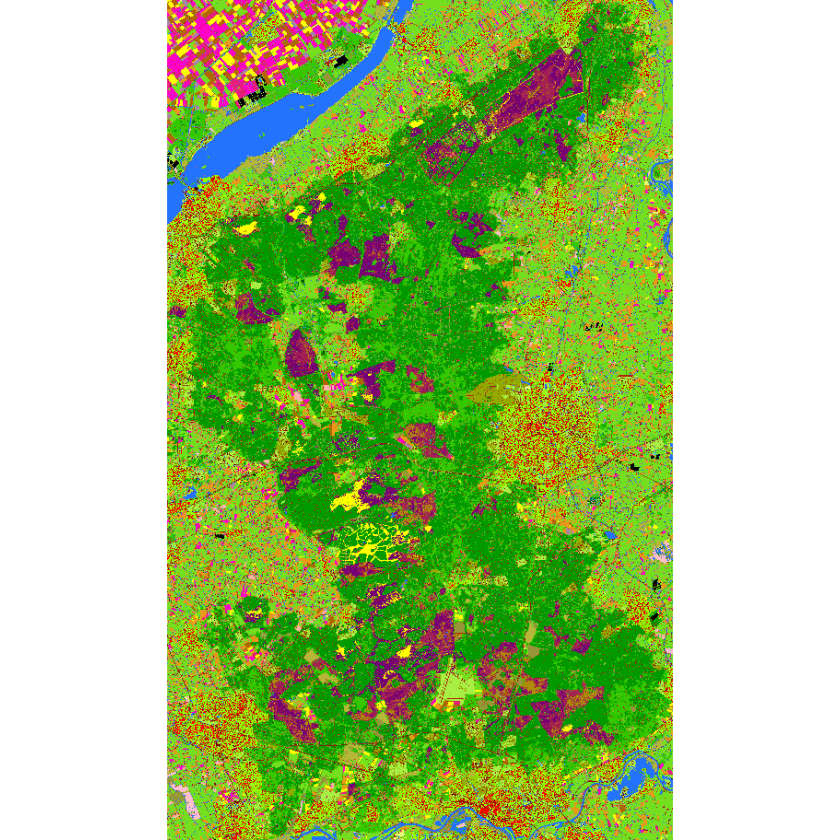

In [4]:
## DO NOT RUN ##
terra::plotRGB(lgn_a)

In [3]:
# Or directly via hard-coded url manipulation:
lgn_b <- terra::rast("https://service.pdok.nl/wur/landelijk-grondgebruik-nederland/wms/v1_0?request=GetMap&service=WMS&version=1.3.0&layers=lgn-actueel&styles=default&crs=epsg:28992&bbox=169365.309999999,441809.7711,203464.2718,498437.694200002&width=1&height=1&format=image/png")

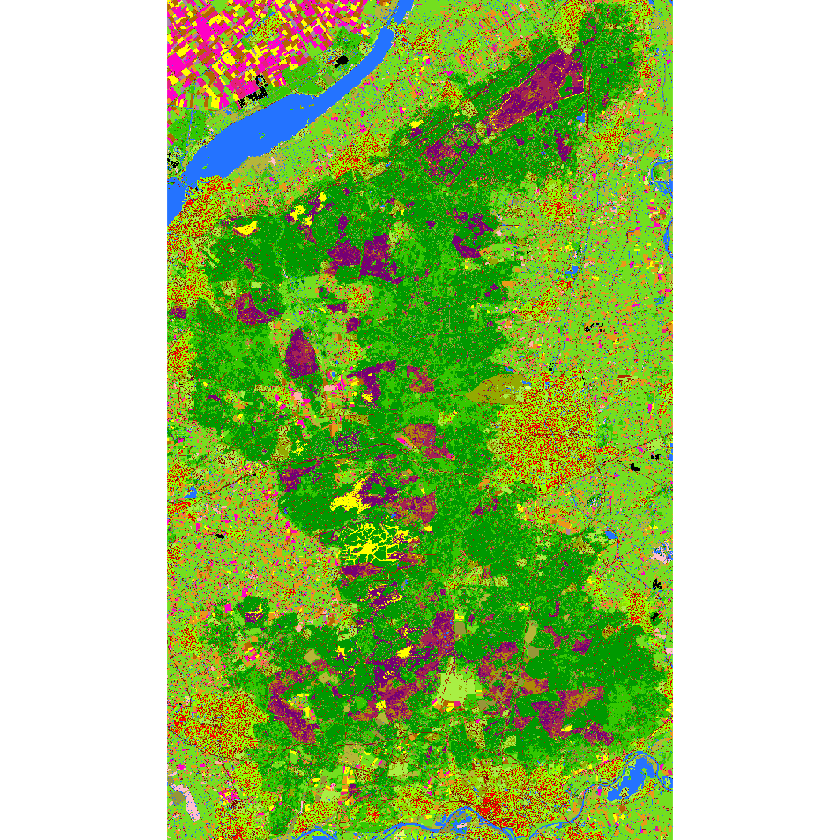

In [4]:
terra::plot(lgn_b)

##### Conclusion
The downside of the WMS service is that it only provides outputs in the form of jpeg or png with size restrictions. We can produce a map but with a much smaller resolution than LGN actually offers (i.e., 5x5 m in recent years).

### LGN via NatureDataCube

*under development*

LGN 2024 is also made available in LTER-LIFE's [NatureDataCube](https://naturedatacube.wur.nl/).
An R package is in development that should make it easy to retrieve the LGN data for our area of interest. Unfortunately, this cannot be installed in the NaaVRE at the moment.  
Another downside is that only the 2024 data are available in the NatureDataCube; if we want older versions, we still have to resort to manual download.

### LGN via website download
For now, the easiest option to access all LGN maps is via the manual download on the website. Data are then available as .tif files, which can be straightforwardly loaded with {terra}.

In [3]:
# For LGN5, which was made in 2003-2004
lgn5 <- terra::rast("~/Cloud Storage/naa-vre-public/vl-veluwe-forest-model/LGN5.tif")

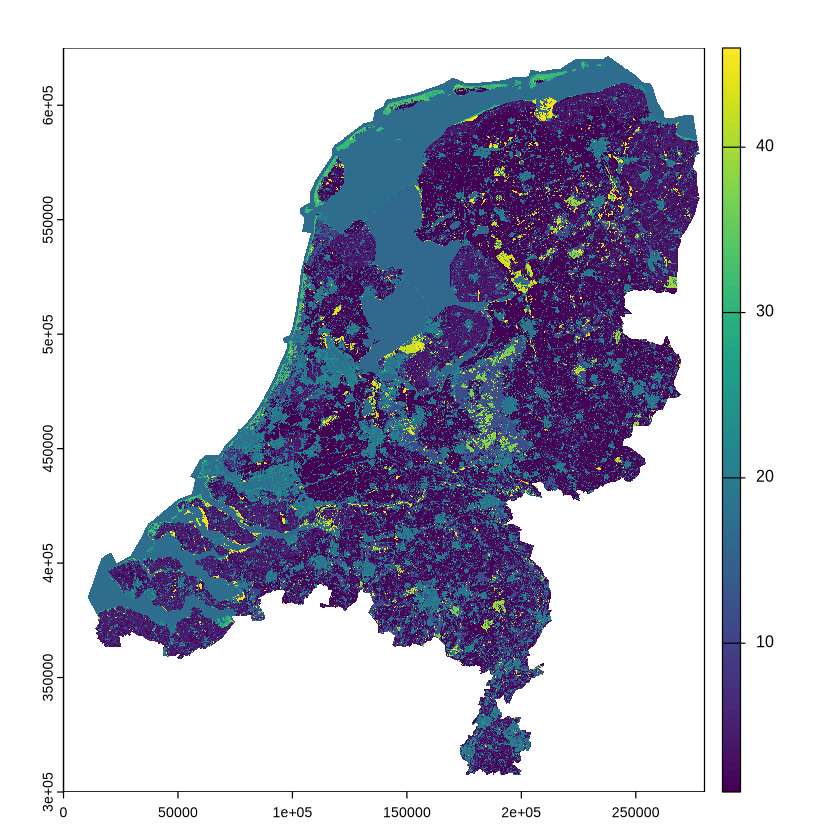

In [4]:
terra::plot(lgn5)

#### To Do
Remaining steps that need to be created this workflow:
- Crop national map to Veluwe using the Natura2000 polygon
- Retain only forests (see land use codes)

The classification they use for LGN has changed through time. An overview of changes is made available (in Dutch only) here: https://lgn.nl/documentatie/wijzigingen-per-versie  
This can be a bit challenging if you want to compare land use through time, but luckily for forests, the codes have always been the same:
- 11: Loofbos, deciduous forest
- 12: Naaldbos, coniferous forest

#### Update
2026-07-21

María Gutiérrez Fuentesal


In [5]:
#Turn sf object into vector
veluwe_v <- vect(veluwe_sf)

In [6]:
#Crop national map to Veluwe using the Natura2000 polygon
lgn5_veluwe <- terra::crop(lgn5, veluwe_v)
lgn5_veluwe <- terra::mask(lgn5_veluwe, veluwe_v)

In [7]:
#Retain only the forest (11 and 12)
forest_codes <- c(11, 12)
veluwe_forest <- terra::ifel(lgn5_veluwe %in% forest_codes, 1, NA)

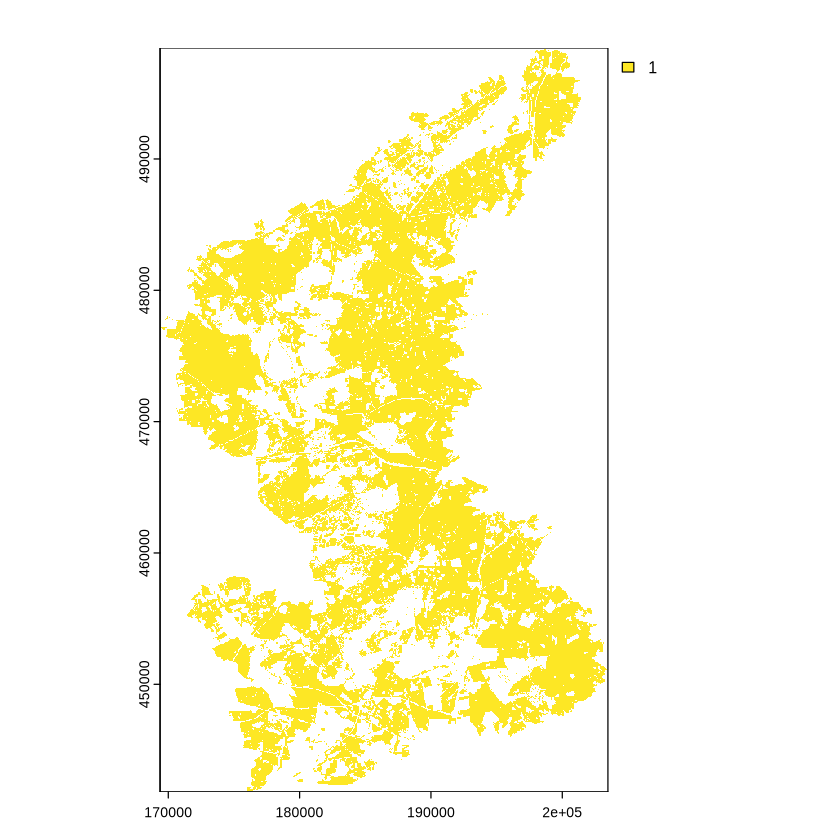

In [9]:
plot(veluwe_forest)

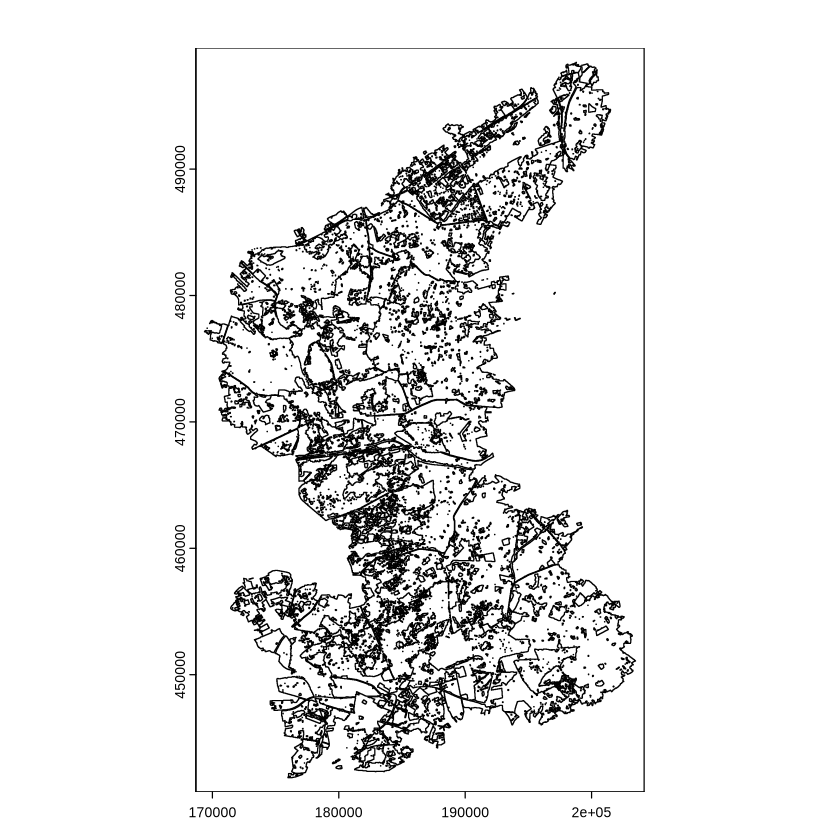

In [8]:
#Turn raster into a polygon 
veluwe_forest_v <- as.polygons(veluwe_forest,aggregate = TRUE,na.rm = TRUE)
terra::plot(veluwe_forest_v)